# SkyClear — Day 1: Pipeline Proof-of-Life
### BAH 2026 — Generative AI Cloud Removal for LISS-IV Imagery

**Goal for today:** get the full pipeline running end-to-end — synthetic clouds → dataset → model → training loop → checkpoint → visible output. Quality is NOT the goal today. Proving the loop works is.

**Before you run anything:**
1. `Runtime → Change runtime type → T4 GPU`
2. Upload 15-20 clean landscape/aerial/satellite images to `MyDrive/BAH2026/data/clean` (any images work today — swap for real LISS-IV once Bhoonidhi is approved)
3. Run cells top to bottom, in order


## Step 0 — Mount Drive & Create Folders

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/BAH2026'
DATA_DIR = f'{BASE}/data/clean'
CKPT_DIR = f'{BASE}/checkpoints'
OUT_DIR = f'{BASE}/outputs'

for d in [DATA_DIR, CKPT_DIR, OUT_DIR]:
    os.makedirs(d, exist_ok=True)

print("Folders ready.")
print(f"Put your clean images in: {DATA_DIR}")
n_images = len([f for f in os.listdir(DATA_DIR) if f.lower().endswith(('.jpg','.jpeg','.png','.tif','.tiff'))])
print(f"Found {n_images} images in data folder.")
if n_images == 0:
    print("!! WARNING: No images found. Upload some to the folder above before continuing.")


Mounted at /content/drive
Folders ready.
Put your clean images in: /content/drive/MyDrive/BAH2026/data/clean
Found 3615 images in data folder.


## Step 1 — Install & Import

In [2]:
!pip install -q rasterio scikit-image albumentations

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import random
import glob
import os
from datetime import datetime

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cpu':
    print("!! No GPU detected. Go to Runtime > Change runtime type > T4 GPU, then re-run.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.5/121.5 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 369.4/369.4 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 583.5/583.5 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 93.7 MB/s eta 0:00:00
Using device: cpu
!! No GPU detected. Go to Runtime > Change runtime type > T4 GPU, then re-run.


## Step 2 — Synthetic Cloud Generator

This is today's core deliverable. It takes a clean image and overlays a realistic fake cloud
using smoothed random noise (a fast, dependency-free stand-in for Perlin noise), so we get
unlimited (cloudy, clean) training pairs without needing real paired data.

In [3]:
def generate_fractal_cloud_mask(size, coverage=0.55, softness=25, seed=None):
    h, w = size
    rng = np.random.RandomState(seed) if seed is not None else np.random

    octaves, persistence, base_res = 4, 0.55, 5
    noise = np.zeros((h, w), dtype=np.float32)
    amplitude, total_amp = 1.0, 0.0

    for o in range(octaves):
        res = max(2, base_res * (2 ** o))
        small = rng.rand(res, res)
        layer = np.array(Image.fromarray((small * 255).astype(np.uint8)).resize((w, h), Image.BICUBIC), dtype=np.float32) / 255.0
        noise += layer * amplitude
        total_amp += amplitude
        amplitude *= persistence
    noise /= total_amp
    noise = gaussian_filter(noise, sigma=softness / 4.0)

    threshold = np.quantile(noise, 1 - coverage)
    mask = np.clip((noise - threshold) / (noise.max() - threshold + 1e-6), 0, 1)

    # push mask toward binary (opaque core) instead of smooth gradient
    mask = mask ** 0.5  # steepens the curve -- more pixels land near 1.0
    mask = gaussian_filter(mask, sigma=softness / 6.0)  # much lighter blur -- only edges feather

    return np.clip(mask, 0, 1).astype(np.float32)


def apply_synthetic_cloud(clean_img, coverage_range=(0.35, 0.7), seed=None, add_shadow=True):
    arr = np.array(clean_img).astype(np.float32) / 255.0
    h, w = arr.shape[:2]

    coverage = random.uniform(*coverage_range)
    mask = generate_fractal_cloud_mask((h, w), coverage=coverage, softness=random.uniform(15, 35), seed=seed)
    result = arr.copy()

    if add_shadow:
        dx, dy = int(w * 0.03), int(h * 0.03)
        shadow_mask = np.roll(mask, shift=(dy, dx), axis=(0, 1))
        result = result * (1 - (shadow_mask * 0.35)[:, :, None])

    cloud_color = np.array([0.94, 0.94, 0.93]) + np.random.uniform(-0.02, 0.02, 3)
    cloud_layer = np.ones_like(arr) * cloud_color
    result = result * (1 - mask[:, :, None]) + cloud_layer * mask[:, :, None]
    result = np.clip(result, 0, 1)

    return Image.fromarray((result * 255).astype(np.uint8)), mask

### Quick visual test — confirm the cloud generator looks reasonable

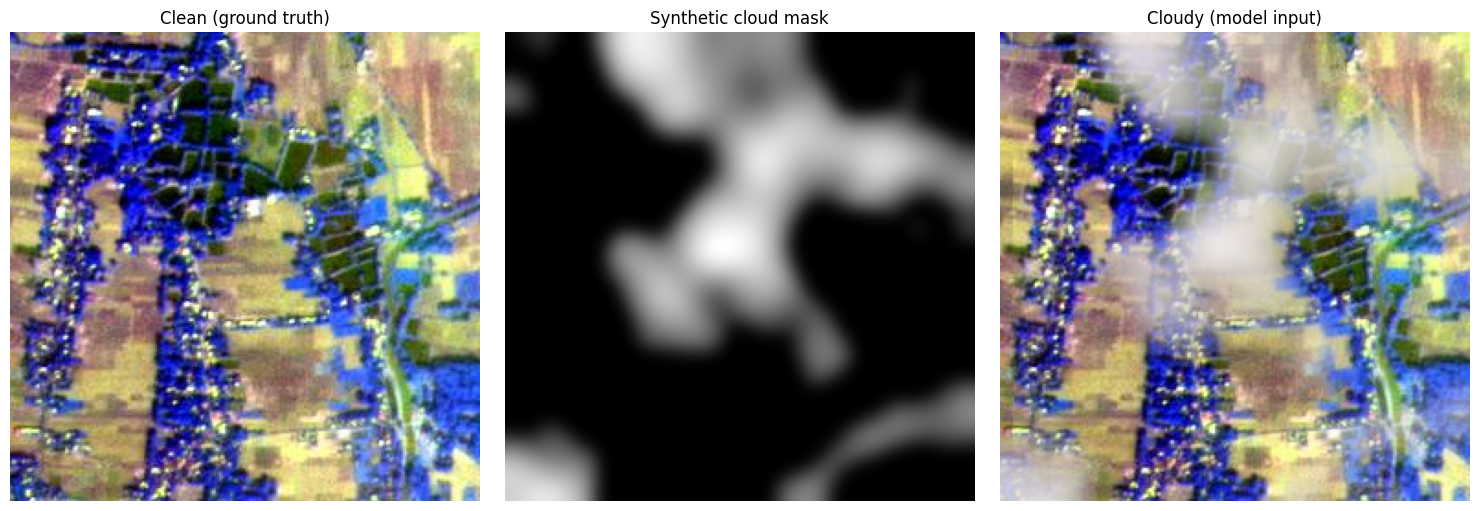

If this looks like a reasonable fake cloud, move to the next step.
If it looks wrong (too blocky / too faint), tweak coverage_range or softness above and re-run.


In [4]:
sample_files = glob.glob(f'{DATA_DIR}/*')
assert len(sample_files) > 0, "No images found in data folder — upload some first."

test_img = Image.open(sample_files[0]).convert('RGB').resize((256, 256))
cloudy_img, mask = apply_synthetic_cloud(test_img, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(test_img); axes[0].set_title('Clean (ground truth)'); axes[0].axis('off')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Synthetic cloud mask'); axes[1].axis('off')
axes[2].imshow(cloudy_img); axes[2].set_title('Cloudy (model input)'); axes[2].axis('off')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/cloud_generator_test.png', dpi=100)
plt.show()
print("If this looks like a reasonable fake cloud, move to the next step.")
print("If it looks wrong (too blocky / too faint), tweak coverage_range or softness above and re-run.")


Bands: 3, Size: 2820x3460, Dtype: ('int16', 'int16', 'int16')


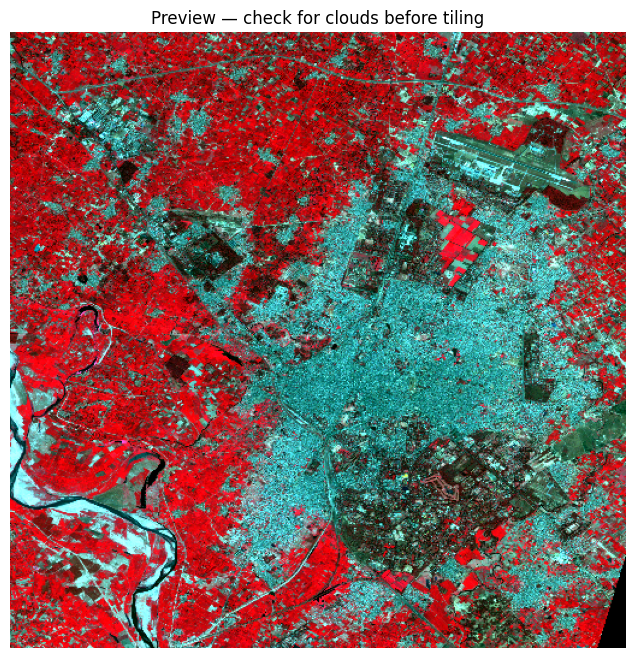

In [5]:
import rasterio
import numpy as np

RAW_TIF = f'{BASE}/data/raw/Bareilyoutput.tif'

with rasterio.open(RAW_TIF) as src:
    print(f"Bands: {src.count}, Size: {src.width}x{src.height}, Dtype: {src.dtypes}")

    bands_to_use = [1, 2, 3] if src.count >= 3 else [1, 1, 1]
    preview = src.read(bands_to_use, out_shape=(3, 512, 512)).astype(np.float32)
    preview = np.transpose(preview, (1, 2, 0))

    def stretch(band):
        lo, hi = np.percentile(band, (2, 98))
        return np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)

    preview_norm = np.stack([stretch(preview[:, :, i]) for i in range(3)], axis=-1)
    plt.figure(figsize=(8, 8))
    plt.imshow(preview_norm)
    plt.title('Preview — check for clouds before tiling')
    plt.axis('off')
    plt.show()

Scene size: 18451 x 16371 pixels


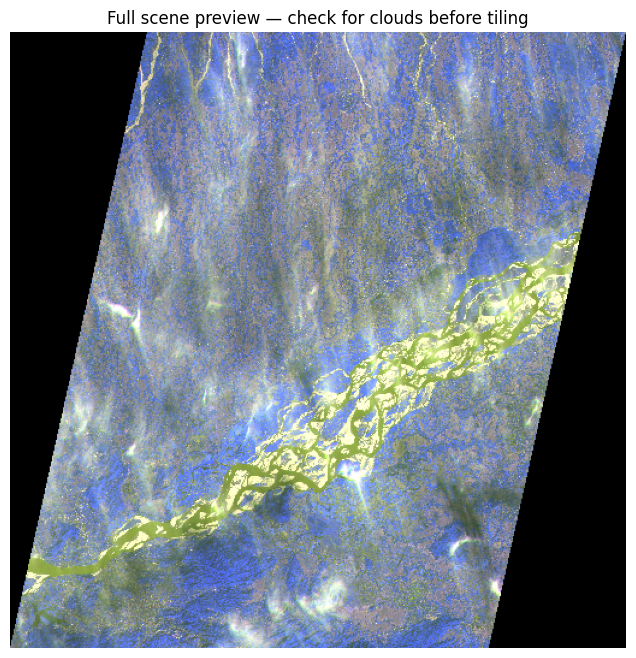

In [6]:
import rasterio
import rasterio.windows

RAW_DIR = f'{BASE}/data/raw'
TILE_SIZE = 256
STRIDE = 256
MIN_VALID_FRACTION = 0.95

green_path = f'{RAW_DIR}/BAND2.tif'
red_path   = f'{RAW_DIR}/BAND3.tif'
nir_path   = f'{RAW_DIR}/BAND4.tif'

with rasterio.open(green_path) as g, rasterio.open(red_path) as r, rasterio.open(nir_path) as n:
    W, H = g.width, g.height
    print(f"Scene size: {W} x {H} pixels")

    preview_g = g.read(1, out_shape=(512, 512)).astype(np.float32)
    preview_r = r.read(1, out_shape=(512, 512)).astype(np.float32)
    preview_n = n.read(1, out_shape=(512, 512)).astype(np.float32)

    def stretch(band):
        lo, hi = np.percentile(band, (2, 98))
        return np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)

    preview_rgb = np.stack([stretch(preview_r), stretch(preview_g), stretch(preview_n)], axis=-1)
    plt.figure(figsize=(8, 8))
    plt.imshow(preview_rgb)
    plt.title('Full scene preview — check for clouds before tiling')
    plt.axis('off')
    plt.show()

In [7]:
from PIL import Image
import rasterio.windows

TILE_SIZE = 256
STRIDE = 256
MIN_VALID_FRACTION = 0.95  # skip mostly-black edge tiles

saved = 0
with rasterio.open(RAW_TIF) as src:
    bands_to_use = [1, 2, 3] if src.count >= 3 else [1, 1, 1]
    W, H = src.width, src.height
    for top in range(0, H - TILE_SIZE, STRIDE):
        for left in range(0, W - TILE_SIZE, STRIDE):
            window = rasterio.windows.Window(left, top, TILE_SIZE, TILE_SIZE)
            tile = src.read(bands_to_use, window=window).astype(np.float32)
            tile = np.transpose(tile, (1, 2, 0))

            if np.mean(tile.sum(axis=-1) > 0) < MIN_VALID_FRACTION:
                continue

            tile_norm = np.stack([stretch(tile[:, :, i]) for i in range(3)], axis=-1)
            Image.fromarray((tile_norm * 255).astype(np.uint8)).save(f'{DATA_DIR}/bareilly_tile_{saved:03d}.jpg')
            saved += 1

print(f"Saved {saved} tiles to {DATA_DIR}")

Saved 142 tiles to /content/drive/MyDrive/BAH2026/data/clean


In [ ]:
saved = 0
with rasterio.open(green_path) as g, rasterio.open(red_path) as r, rasterio.open(nir_path) as n:
    W, H = g.width, g.height
    for top in range(0, H - TILE_SIZE, STRIDE):
        for left in range(0, W - TILE_SIZE, STRIDE):
            window = rasterio.windows.Window(left, top, TILE_SIZE, TILE_SIZE)

            g_tile = g.read(1, window=window).astype(np.float32)
            r_tile = r.read(1, window=window).astype(np.float32)
            n_tile = n.read(1, window=window).astype(np.float32)

            # skip mostly-black (no-data) tiles, e.g. near the skewed scene edges
            if np.mean(g_tile > 0) < MIN_VALID_FRACTION:
                continue

            tile_rgb = np.stack([stretch(r_tile), stretch(g_tile), stretch(n_tile)], axis=-1)
            Image.fromarray((tile_rgb * 255).astype(np.uint8)).save(f'{DATA_DIR}/liss4_dec2025_tile_{saved:03d}.jpg')
            saved += 1

print(f"Saved {saved} real LISS-IV tiles to {DATA_DIR}")

## Step 3 — Dataset

In [ ]:
IMG_SIZE = 128

class SyntheticCloudDataset(Dataset):
    def __init__(self, image_dir, img_size=IMG_SIZE):
        self.files = glob.glob(f'{image_dir}/*.jpg') + glob.glob(f'{image_dir}/*.jpeg') + \
                     glob.glob(f'{image_dir}/*.png') + glob.glob(f'{image_dir}/*.tif') + \
                     glob.glob(f'{image_dir}/*.tiff')
        self.img_size = img_size
        assert len(self.files) > 0, f"No images found in {image_dir}"

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('RGB').resize((self.img_size, self.img_size))
        cloudy_img, mask = apply_synthetic_cloud(img)

        clean_t = torch.from_numpy(np.array(img).astype(np.float32) / 127.5 - 1.0).permute(2, 0, 1)
        cloudy_t = torch.from_numpy(np.array(cloudy_img).astype(np.float32) / 127.5 - 1.0).permute(2, 0, 1)
        mask_t = torch.from_numpy(mask).unsqueeze(0)

        return cloudy_t, clean_t, mask_t


dataset = SyntheticCloudDataset(DATA_DIR)
print(f"Dataset size: {len(dataset)} images")

# Bigger batch size now that we have a real dataset -- T4 can handle this easily at 128x128
BATCH_SIZE = 32
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                         num_workers=2, pin_memory=True)
print(f"Batch size: {BATCH_SIZE}, batches per epoch: {len(dataloader)}")

## Step 4 — Model

A small U-Net generator + a lightweight PatchGAN discriminator (pix2pix-style).
Kept deliberately small/simple so it trains fast today on a T4. This is your safety-net
architecture — swap in the diffusion+LoRA approach later once this baseline works.

In [ ]:
class UNetGenerator(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, base=32):
        super().__init__()
        def block(i, o, down=True):
            layers = [nn.Conv2d(i, o, 4, 2, 1) if down else nn.ConvTranspose2d(i, o, 4, 2, 1)]
            layers.append(nn.InstanceNorm2d(o))
            layers.append(nn.LeakyReLU(0.2) if down else nn.ReLU())
            return nn.Sequential(*layers)

        self.e1 = nn.Conv2d(in_ch, base, 4, 2, 1)             # 128 -> 64
        self.e2 = block(base, base*2)                          # 64 -> 32
        self.e3 = block(base*2, base*4)                        # 32 -> 16
        self.e4 = block(base*4, base*8)                        # 16 -> 8

        self.d1 = block(base*8, base*4, down=False)            # 8 -> 16
        self.d2 = block(base*8, base*2, down=False)            # 16 -> 32 (concat skip)
        self.d3 = block(base*4, base, down=False)               # 32 -> 64 (concat skip)
        self.d4 = nn.ConvTranspose2d(base*2, out_ch, 4, 2, 1)   # 64 -> 128 (concat skip)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(F.leaky_relu(e1, 0.2))
        e3 = self.e3(e2)
        e4 = self.e4(e3)

        d1 = self.d1(F.relu(e4))
        d2 = self.d2(torch.cat([d1, e3], 1))
        d3 = self.d3(torch.cat([d2, e2], 1))
        d4 = self.d4(torch.cat([d3, e1], 1))
        return torch.tanh(d4)


class PatchDiscriminator(nn.Module):
    def __init__(self, in_ch=6, base=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(base, base*2, 4, 2, 1), nn.InstanceNorm2d(base*2), nn.LeakyReLU(0.2),
            nn.Conv2d(base*2, base*4, 4, 2, 1), nn.InstanceNorm2d(base*4), nn.LeakyReLU(0.2),
            nn.Conv2d(base*4, 1, 4, 1, 1)
        )

    def forward(self, img_a, img_b):
        x = torch.cat([img_a, img_b], 1)
        return self.net(x)


generator = UNetGenerator().to(device)
discriminator = PatchDiscriminator().to(device)
print("Models built.")
print(f"Generator params: {sum(p.numel() for p in generator.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in discriminator.parameters()):,}")


## Step 5 — Losses, Optimizers, Checkpointing

In [ ]:
criterion_gan = nn.MSELoss()      # LSGAN-style stability, easier to train than vanilla BCE GAN
criterion_l1 = nn.L1Loss()        # pixel-level reconstruction loss

opt_g = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

L1_LAMBDA = 150  # weight on reconstruction loss vs adversarial loss (standard pix2pix value)


def save_checkpoint(epoch):
    path = f'{CKPT_DIR}/skyclear_epoch{epoch}.pt'
    torch.save({
        'epoch': epoch,
        'generator': generator.state_dict(),
        'discriminator': discriminator.state_dict(),
        'opt_g': opt_g.state_dict(),
        'opt_d': opt_d.state_dict(),
    }, path)
    print(f"  Checkpoint saved -> {path}")


def load_checkpoint(path):
    ckpt = torch.load(path, map_location=device)
    generator.load_state_dict(ckpt['generator'])
    discriminator.load_state_dict(ckpt['discriminator'])
    opt_g.load_state_dict(ckpt['opt_g'])
    opt_d.load_state_dict(ckpt['opt_d'])
    print(f"Resumed from epoch {ckpt['epoch']}")
    return ckpt['epoch']

print("Ready to train. If Colab disconnects, re-run cells 0-5, then call:")
print("  load_checkpoint(f'{CKPT_DIR}/skyclear_epoch<N>.pt')")
print("before re-running the training loop, to resume instead of starting over.")


## Step 6 — Training Loop (Proof-of-Life Run)

This runs a small number of epochs just to prove the pipeline works end-to-end and loss
decreases. Today's win = seeing a before/after image that looks *closer* to the ground
truth than the cloudy input, even if it's rough. Longer training comes once real LISS-IV
data is in and this loop is confirmed working.

In [12]:
EPOCHS_TODAY = 36

for epoch in range(35, EPOCHS_TODAY):
    g_losses, d_losses = [], []
    for cloudy, clean, mask in dataloader:
        cloudy, clean = cloudy.to(device), clean.to(device)

        opt_d.zero_grad()
        fake = generator(cloudy)
        pred_real = discriminator(cloudy, clean)
        pred_fake = discriminator(cloudy, fake.detach())
        loss_d = 0.5 * (criterion_gan(pred_real, torch.ones_like(pred_real)) +
                         criterion_gan(pred_fake, torch.zeros_like(pred_fake)))
        loss_d.backward()
        opt_d.step()

        opt_g.zero_grad()
        pred_fake = discriminator(cloudy, fake)
        loss_g_gan = criterion_gan(pred_fake, torch.ones_like(pred_fake))
        loss_g_l1 = criterion_l1(fake, clean) * L1_LAMBDA
        loss_g = loss_g_gan + loss_g_l1
        loss_g.backward()
        opt_g.step()

        g_losses.append(loss_g.item())
        d_losses.append(loss_d.item())

    print(f"Epoch {epoch+1}/{EPOCHS_TODAY} | G loss: {np.mean(g_losses):.3f} | D loss: {np.mean(d_losses):.3f}")
    save_checkpoint(epoch + 1)  # save every epoch now, since each one is a big chunk of work

Epoch 36/36 | G loss: 41.259 | D loss: 0.215
  Checkpoint saved -> /content/drive/MyDrive/BAH2026/checkpoints/skyclear_epoch36.pt


In [6]:
start_epoch = load_checkpoint(f'{CKPT_DIR}/skyclear_epoch65.pt')

NameError: name 'load_checkpoint' is not defined

In [32]:
start_epoch = load_checkpoint(f'{CKPT_DIR}/skyclear_epoch35.pt')

EPOCHS_TODAY = start_epoch + 30

for epoch in range(start_epoch, EPOCHS_TODAY):
    g_losses, d_losses = [], []
    for cloudy, clean, mask in dataloader:
        cloudy, clean = cloudy.to(device), clean.to(device)

        opt_d.zero_grad()
        fake = generator(cloudy)
        pred_real = discriminator(cloudy, clean)
        pred_fake = discriminator(cloudy, fake.detach())
        loss_d = 0.5 * (criterion_gan(pred_real, torch.ones_like(pred_real)) +
                         criterion_gan(pred_fake, torch.zeros_like(pred_fake)))
        loss_d.backward()
        opt_d.step()

        opt_g.zero_grad()
        pred_fake = discriminator(cloudy, fake)
        loss_g_gan = criterion_gan(pred_fake, torch.ones_like(pred_fake))
        loss_g_l1 = criterion_l1(fake, clean) * L1_LAMBDA
        loss_g = loss_g_gan + loss_g_l1
        loss_g.backward()
        opt_g.step()

        g_losses.append(loss_g.item())
        d_losses.append(loss_d.item())

    print(f"Epoch {epoch+1}/{EPOCHS_TODAY} | G loss: {np.mean(g_losses):.3f} | D loss: {np.mean(d_losses):.3f}")
    save_checkpoint(epoch + 1)

print(f"\nTraining complete. Resumed from epoch {start_epoch}, trained to epoch {EPOCHS_TODAY}.")

Resumed from epoch 35
Epoch 36/65 | G loss: 11.067 | D loss: 0.052
  Checkpoint saved -> /content/drive/MyDrive/BAH2026/checkpoints/skyclear_epoch36.pt
Epoch 37/65 | G loss: 11.038 | D loss: 0.052
  Checkpoint saved -> /content/drive/MyDrive/BAH2026/checkpoints/skyclear_epoch37.pt
Epoch 38/65 | G loss: 11.098 | D loss: 0.059
  Checkpoint saved -> /content/drive/MyDrive/BAH2026/checkpoints/skyclear_epoch38.pt
Epoch 39/65 | G loss: 11.168 | D loss: 0.066
  Checkpoint saved -> /content/drive/MyDrive/BAH2026/checkpoints/skyclear_epoch39.pt
Epoch 40/65 | G loss: 11.147 | D loss: 0.067
  Checkpoint saved -> /content/drive/MyDrive/BAH2026/checkpoints/skyclear_epoch40.pt
Epoch 41/65 | G loss: 11.075 | D loss: 0.074
  Checkpoint saved -> /content/drive/MyDrive/BAH2026/checkpoints/skyclear_epoch41.pt
Epoch 42/65 | G loss: 11.132 | D loss: 0.070
  Checkpoint saved -> /content/drive/MyDrive/BAH2026/checkpoints/skyclear_epoch42.pt
Epoch 43/65 | G loss: 11.110 | D loss: 0.062
  Checkpoint saved -> /

## Step 7 — Visualize a Result

In [1]:
generator.eval()
with torch.no_grad():
    cloudy, clean, mask = next(iter(dataloader))
    cloudy, clean = cloudy.to(device), clean.to(device)
    fake = generator(cloudy)

def to_img(t):
    t = (t.cpu().numpy().transpose(1, 2, 0) + 1) / 2
    return np.clip(t, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(to_img(cloudy[0])); axes[0].set_title('Cloudy Input'); axes[0].axis('off')
axes[1].imshow(to_img(fake[0])); axes[1].set_title('Model Output (Day 1)'); axes[1].axis('off')
axes[2].imshow(to_img(clean[0])); axes[2].set_title('Ground Truth'); axes[2].axis('off')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/day1_result.png', dpi=100)
plt.show()

generator.train()
print(f"Saved to {OUT_DIR}/day1_result.png")
print("\nThis is your Day 1 deliverable: proof the full pipeline runs end-to-end.")
print("Don't judge quality yet — 15 epochs on a handful of test images is just a smoke test.")


NameError: name 'generator' is not defined

## Step 8 — Quick Quality Check (PSNR / SSIM)

Just to see the numbers move — not meaningful yet with this little training, but confirms
your eval code works before you need it for real.

In [19]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

fake_np = to_img(fake[0])
clean_np = to_img(clean[0])

psnr_val = psnr(clean_np, fake_np, data_range=1.0)
ssim_val = ssim(clean_np, fake_np, data_range=1.0, channel_axis=2)

print(f"PSNR: {psnr_val:.2f} dB")
print(f"SSIM: {ssim_val:.3f}")
print("\n(Expect low/rough numbers today — this is 15 epochs on a tiny test set.")
print(" Once real LISS-IV data + full training is in, these should climb meaningfully.)")


PSNR: 25.67 dB
SSIM: 0.953

(Expect low/rough numbers today — this is 15 epochs on a tiny test set.
 Once real LISS-IV data + full training is in, these should climb meaningfully.)


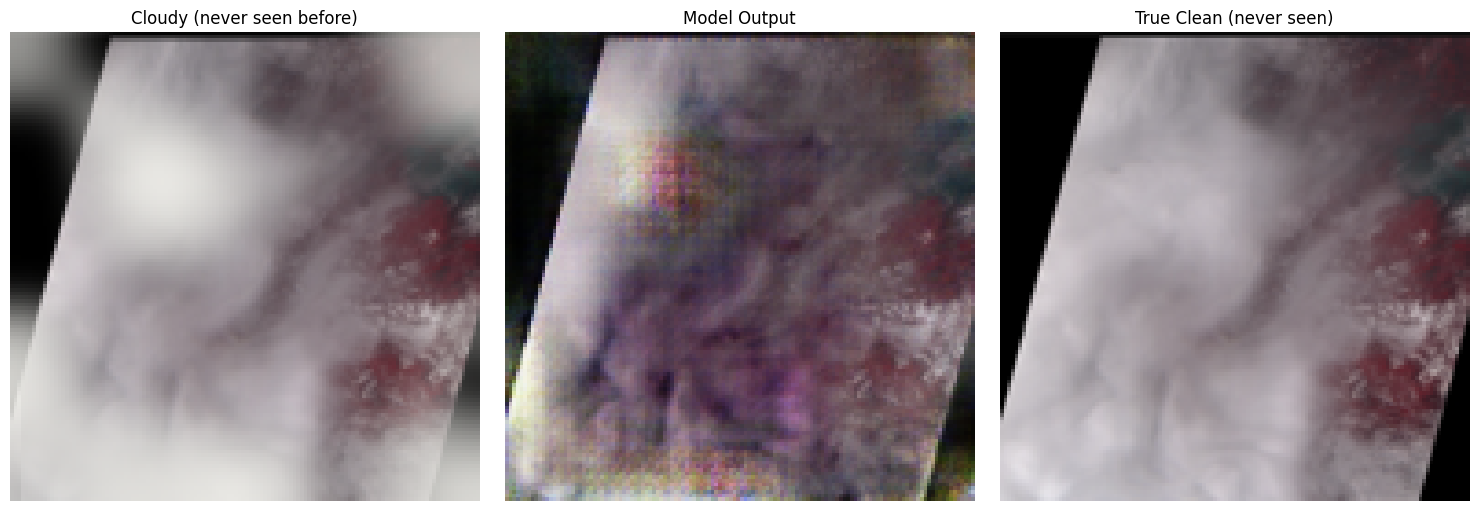

Holdout PSNR: 14.28 dB
Holdout SSIM: 0.599


In [20]:
test_img_path = f'{BASE}/test_holdout/new_test.png'
test_img = Image.open(test_img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
cloudy_test, mask_test = apply_synthetic_cloud(test_img, seed=123)

cloudy_t = torch.from_numpy(np.array(cloudy_test).astype(np.float32)/127.5 - 1.0).permute(2,0,1).unsqueeze(0).to(device)

generator.eval()
with torch.no_grad():
    fake_test = generator(cloudy_t)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cloudy_test); axes[0].set_title('Cloudy (never seen before)'); axes[0].axis('off')
axes[1].imshow(to_img(fake_test[0])); axes[1].set_title('Model Output'); axes[1].axis('off')
axes[2].imshow(test_img); axes[2].set_title('True Clean (never seen)'); axes[2].axis('off')
plt.tight_layout()
plt.show()
generator.train()

# quick numbers for this one holdout image too
test_np = np.array(test_img).astype(np.float32) / 255.0
fake_test_np = to_img(fake_test[0])
holdout_psnr = psnr(test_np, fake_test_np, data_range=1.0)
holdout_ssim = ssim(test_np, fake_test_np, data_range=1.0, channel_axis=2)
print(f"Holdout PSNR: {holdout_psnr:.2f} dB")
print(f"Holdout SSIM: {holdout_ssim:.3f}")

---
## What's done today vs. what's next

**Done today (if all cells ran):**
- Synthetic cloud generator, verified visually
- Data pipeline (Dataset/DataLoader)
- U-Net GAN model, training loop, checkpointing to Drive
- A trained-model output, even if rough
- Working PSNR/SSIM eval code

**Next (once Bhoonidhi access is approved):**
1. Swap the `DATA_DIR` folder contents for real cloud-free LISS-IV tiles
2. Increase `IMG_SIZE`, `EPOCHS_TODAY` (rename to real epoch count), and dataset size
3. Train properly (likely several hours across sessions — use `load_checkpoint` to resume)
4. Test on *real* cloudy LISS-IV scenes (not synthetic) using non-reference metrics (NIQE, BRISQUE)
5. Optional stretch: swap this GAN for the diffusion + LoRA approach once this baseline is solid
